In [1]:
#Define library
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
from google.colab import drive
drive.mount("/content/drive/")

Mounted at /content/drive/


# **Part 1: Data Exploration (10 Marks)**

## **Task 1**

In [3]:
#Specify the file driectory
df = pd.read_csv("/content/drive/MyDrive/oil_sales_assignment_dataset.csv")

In [ ]:
#first 5 rows
df.head()

,city,store_name,manufacturer,brand,class,size,sku,price_bracket,year,month,value_sales,volume_sales,average_price
0,AL BAHA,HM No 57296 GS-CENTER-AL BAHA MAIN RD AL BAHA,NOVA FOODS,LARA,COCONUT,0.75L,LARA COCONUT 0.75L TWIN PACK,21-30,2024,12,830.86,30.1,27.6
1,AL KHARJ,HM No 55697 GS-CENTER-AL KHARJ MAIN RD AL K...,PALM & GRAIN GROUP,NAJMA,CANOLA,0.5L,NAJMA CANOLA 0.5L TWIN PACK,41-50,2024,10,373.10,9.1,41.0
2,RIYADH,HM No 86781 GS-CENTER-RIYADH MAIN RD RIYADH,AL HILAL INDUSTRIES,BAYTNA,SUNFLOWER,0.75L,BAYTNA SUNFLOWER 0.75L ECO,101+,2023,1,171.70,1.7,101.0
3,DAMMAM,HM No 95753 GS-CENTER-DAMMAM MAIN RD DAMMAM,PALM & GRAIN GROUP,NOUR,CORN,0.6L,NOUR CORN 0.6L TWIN PACK,61-70,2022,2,1226.10,20.1,61.0
4,JAZAN,HM No 56338 GS-CENTER-JAZAN MAIN RD JAZAN,DESERT SUN CO,NOUR,VEGETABLE,1L,NOUR VEGETABLE 1L,81-90,2024,2,996.30,12.3,81.0


In [ ]:
#last 5 rows
df.tail()

,city,store_name,manufacturer,brand,class,size,sku,price_bracket,year,month,value_sales,volume_sales,average_price
1995,TABUK,HM No 99317 GS-CENTER-TABUK MAIN RD TABUK,NAJDI CONSUMER,LARA,COCONUT,0.5L,LARA COCONUT 0.5L PREMIUM,31-40,2024,11,74.4,2.4,31.0
1996,AL AHSA,HM No 85390 GS-CENTER-AL AHSA MAIN RD AL AHSA,BLUE OASIS CO,LARA,SUNFLOWER,3L,LARA SUNFLOWER 3L,31-40,2022,5,20.0,0.5,40.0
1997,AL KHARJ,HM No 90740 GS-CENTER-AL KHARJ MAIN RD AL K...,NOVA FOODS,NOUR,SUNFLOWER,2.9L,NOUR SUNFLOWER 2.9L,91-100,2023,8,527.8,5.8,91.0
1998,RIYADH,HM No 52893 GS-CENTER-RIYADH MAIN RD RIYADH,NOVA FOODS,NAJMA,CORN,0.75L,NAJMA CORN 0.75L ECO,61-70,2024,6,305.0,5.0,61.0
1999,JEDDAH,HM No 73689 GS-CENTER-JEDDAH MAIN RD JEDDAH,NAJDI CONSUMER,BAYTNA,COCONUT,1.8L,BAYTNA COCONUT 1.8L ECO,101+,2022,4,181.8,1.8,101.0


In [ ]:
#How many rows and columns?
df.shape

(2000, 13)

There are 2000 rows and 13 column


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 13 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   city           2000 non-null   object 
 1   store_name     2000 non-null   object 
 2   manufacturer   2000 non-null   object 
 3   brand          2000 non-null   object 
 4   class          2000 non-null   object 
 5   size           2000 non-null   object 
 6   sku            2000 non-null   object 
 7   price_bracket  2000 non-null   object 
 8   year           2000 non-null   int64  
 9   month          2000 non-null   int64  
 10  value_sales    2000 non-null   float64
 11  volume_sales   2000 non-null   float64
 12  average_price  2000 non-null   float64
dtypes: float64(3), int64(2), object(8)
memory usage: 203.3+ KB


8 catagorical and 5 number values

In [ ]:
#check for missing value
df.isnull().sum()

,0
city,0
store_name,0
manufacturer,0
brand,0
class,0
size,0
sku,0
price_bracket,0
year,0
month,0


No missing value

In [ ]:
#Generate descriptive statistics.
df.describe()

,year,month,value_sales,volume_sales,average_price
count,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000
mean,2022.990500,6.639500,614.839355,9.972100,60.990230
std,0.820211,3.468942,750.794991,9.862369,29.457029
min,2022.000000,1.000000,6.960000,0.500000,11.000000
25%,2022.000000,4.000000,132.000000,2.900000,37.337500
50%,2023.000000,7.000000,368.320000,7.000000,61.000000
75%,2024.000000,10.000000,794.100000,13.800000,81.000000
max,2024.000000,12.000000,6253.200000,81.700000,140.000000


# **Part 2: Data Preparation**

In [ ]:
#Check the lists in the catagory
categorical_columns = [
    'city',
    'store_name',
    'manufacturer',
    'brand',
    'class',
    'size',
    'sku',
    'price_bracket'
]

for col in categorical_columns:
    print(f"\n{'='*60}")
    print(f"Column: {col}")
    print(f"Number of unique values: {df[col].nunique()}")
    print(df[col].sort_values().unique())


Column: city
Number of unique values: 12
['AL AHSA' 'AL BAHA' 'AL KHARJ' 'DAMMAM' 'HAIL' 'JAZAN' 'JEDDAH' 'MAKKAH'
 'RIYADH' 'TABUK' 'TAIF' 'YANBU']

Column: store_name
Number of unique values: 1997
['HM No  50011  GS-CENTER-AL KHARJ MAIN RD  AL KHARJ'
 'HM No  50013  GS-CENTER-AL AHSA MAIN RD  AL AHSA'
 'HM No  50037  GS-CENTER-DAMMAM MAIN RD  DAMMAM' ...
 'HM No  99973  GS-CENTER-JEDDAH MAIN RD  JEDDAH'
 'HM No  99988  GS-CENTER-JEDDAH MAIN RD  JEDDAH'
 'HM No  99994  GS-CENTER-JEDDAH MAIN RD  JEDDAH']

Column: manufacturer
Number of unique values: 8
['AL HILAL INDUSTRIES' 'ARABIAN HARVEST CO' 'BLUE OASIS CO'
 'DESERT SUN CO' 'NAJDI CONSUMER' 'NOVA FOODS' 'PALM & GRAIN GROUP'
 'SAHARA EDIBLES']

Column: brand
Number of unique values: 10
['BAYTNA' 'GULF GOLD' 'HILAL' 'LARA' 'NAJMA' 'NOUR' 'RAWABI' 'RIMAL'
 'SABAYA' 'ZAHRA']

Column: class
Number of unique values: 5
['CANOLA' 'COCONUT' 'CORN' 'SUNFLOWER' 'VEGETABLE']

Column: size
Number of unique values: 13
['0.2L' '0.5L' '0.6L' '0.7

Drop
*   store_name
*   sku

Label Encode


*   city
*   manufacturer
*   brand
*  class

Convert to numeric
*  size → remove "L" and convert to float

Ordinal Encode
*  price_bracket

Standardize (for Linear Regression)
*  size
*  price_bracket
*  year
*  month
*  average_price
*  volum_sales

In [ ]:
#Drop uncessary column
df = df.drop(columns=['store_name', 'sku'])

In [ ]:
#Convert size to numeric
df['size'] = df['size'].str.replace('L', '', regex=False).astype(float)

In [ ]:
#ordinal encode price bracket
price_map = {
    '11-20$': 1,
    '21-30': 2,
    '31-40': 3,
    '41-50': 4,
    '51-60': 5,
    '61-70': 6,
    '71-80': 7,
    '81-90': 8,
    '91-100': 9,
    '101+': 10
}

df['price_bracket'] = df['price_bracket'].map(price_map)

In [ ]:
#Use labelencoder to encode
from sklearn.preprocessing import LabelEncoder
catagory=["city","manufacturer","brand","class"]
for col in catagory:
    df[col] = LabelEncoder().fit_transform(df[col])

In [ ]:
df.head()

,city,manufacturer,brand,class,size,price_bracket,year,month,value_sales,volume_sales,average_price
0,1,5,3,1,0.75,2,2024,12,830.86,30.1,27.6
1,2,6,4,0,0.50,4,2024,10,373.10,9.1,41.0
2,8,0,0,3,0.75,10,2023,1,171.70,1.7,101.0
3,3,6,5,2,0.60,6,2022,2,1226.10,20.1,61.0
4,5,3,5,4,1.00,8,2024,2,996.30,12.3,81.0


# **Part 3: Univariate Linear Regression**

In [ ]:
X = df[['average_price']]
y = df['value_sales']

# 2. Split the data into Training and Testing sets (e.g., 80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42)
model = LinearRegression()
model.fit(X_train, y_train)

LinearRegression()

In [ ]:
#Predict
train_predictions=model.predict(X_train)
test_predictions=model.predict(X_test)

In [ ]:
#Cof and inter
intercept=model.intercept_
coefficient = model.coef_[0]
print(intercept)
print(coefficient)

-27.280591541652143
10.50790977366243


Interpretation: When the average price increases by one unit, value sales are predicted to increase by 10.51 units

In [ ]:
#Evaluate the prediction
train_rmse=np.sqrt(mean_squared_error(y_train,train_predictions))
test_rmse=np.sqrt(mean_squared_error(y_test,test_predictions))
train_r2= r2_score(y_train,train_predictions)
test_r2=r2_score(y_test,test_predictions)

print(f"Train RMSE: {train_rmse:.2f}")
print(f"Test RMSE: {test_rmse:.2f}")
print(f"Train R^2: {train_r2:.2f}")
print(f"Test R^2: {test_r2:.2f}")

Train RMSE: 687.86
Test RMSE: 674.03
Train R^2: 0.17
Test R^2: 0.14


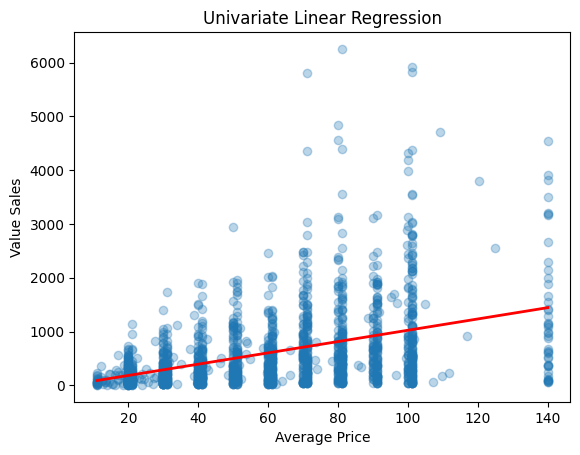

In [ ]:
#Plot the regression line
plt.scatter(X_train, y_train,alpha=0.3)
X_sorted=X_train.sort_values("average_price")
y_sorted= model.predict(X_sorted)
plt.plot(
    X_sorted,
    y_sorted,
    color="red",
    linewidth=2
)
plt.xlabel("Average Price")
plt.ylabel("Value Sales")
plt.title("Univariate Linear Regression")
plt.show()



# **Part 4: Multivariate Linear Regression**

In [ ]:
df.head()

,city,manufacturer,brand,class,size,price_bracket,year,month,value_sales,volume_sales,average_price
0,1,5,3,1,0.75,2,2024,12,830.86,30.1,27.6
1,2,6,4,0,0.50,4,2024,10,373.10,9.1,41.0
2,8,0,0,3,0.75,10,2023,1,171.70,1.7,101.0
3,3,6,5,2,0.60,6,2022,2,1226.10,20.1,61.0
4,5,3,5,4,1.00,8,2024,2,996.30,12.3,81.0


In [ ]:
#Select feature
features = [
    'average_price',
    'volume_sales',
    'year',
    'month',
    'city',
    'manufacturer',
    'brand',
    'class',
    'price_bracket',
    'size'
]
X = df[features]
y = df['value_sales']


In [ ]:
#Split the dataset
X_train_multi,X_test_multi,y_train_multi,y_test_multi=train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [ ]:
#Standardize features
scaler=StandardScaler()
X_train_multi=scaler.fit_transform(X_train_multi)
X_test_multi=scaler.transform(X_test_multi)

In [ ]:
#train the model
model = LinearRegression()
model.fit(X_train_multi, y_train_multi)

LinearRegression()

In [ ]:
#intercept
print("Intercept:", model.intercept_)

Intercept: 617.12899375


In [ ]:
#Display feature importance
coefficients=pd.DataFrame({
    "Features":features,
    "Coefficients":model.coef_
})
coefficients["Absolute"]=coefficients["Coefficients"].abs()
coefficients.sort_values(
    "Absolute",
    ascending=False,
    inplace=True
)
coefficients

,Features,Coefficients,Absolute
1,volume_sales,626.785344,626.785344
0,average_price,280.626566,280.626566
8,price_bracket,10.752845,10.752845
4,city,10.072886,10.072886
3,month,-8.212179,8.212179
7,class,-6.245668,6.245668
9,size,6.071527,6.071527
5,manufacturer,3.279599,3.279599
6,brand,1.461154,1.461154
2,year,0.076969,0.076969


In [ ]:
#Make Prediction
multi_train_predictions=model.predict(X_train_multi)
multi_test_predictions=model.predict(X_test_multi)

In [ ]:
#Evaluate the model
train_rmse_multi=np.sqrt(mean_squared_error(y_train_multi, multi_train_predictions))
test_rmse_multi=np.sqrt(mean_squared_error(y_test_multi, multi_test_predictions))
train_r2_multi=r2_score(y_train_multi,multi_train_predictions)
test_r2_multi=r2_score(y_test_multi,multi_test_predictions)
print(f"Train RMSE: {train_rmse_multi:.2f}")
print(f"Test RMSE: {test_rmse_multi:.2f}")
print(f"Train R^2: {train_r2_multi:.2f}")
print(f"Test R^2: {test_r2_multi:.2f}")

Train RMSE: 283.62
Test RMSE: 296.47
Train R^2: 0.86
Test R^2: 0.83


## **Part 5: Model Comparison**

In [ ]:
#Create a Comparison Table
comparison=pd.DataFrame({
"Model": [
"Univariate (Average Price)",
"Multivariate (All Features)"
],
"Train RMSE": [train_rmse, train_rmse_multi],
"Test RMSE": [test_rmse, test_rmse_multi],
"Train R²": [train_r2, train_r2_multi],
"Test R²": [test_r2, test_r2_multi]
})

print("Model Performance Comparison")
print(comparison.round(2))

Model Performance Comparison
                         Model  Train RMSE  Test RMSE  Train R²  Test R²
0   Univariate (Median Income)      687.86     674.03      0.17     0.14
1  Multivariate (All Features)      283.62     296.47      0.86     0.83


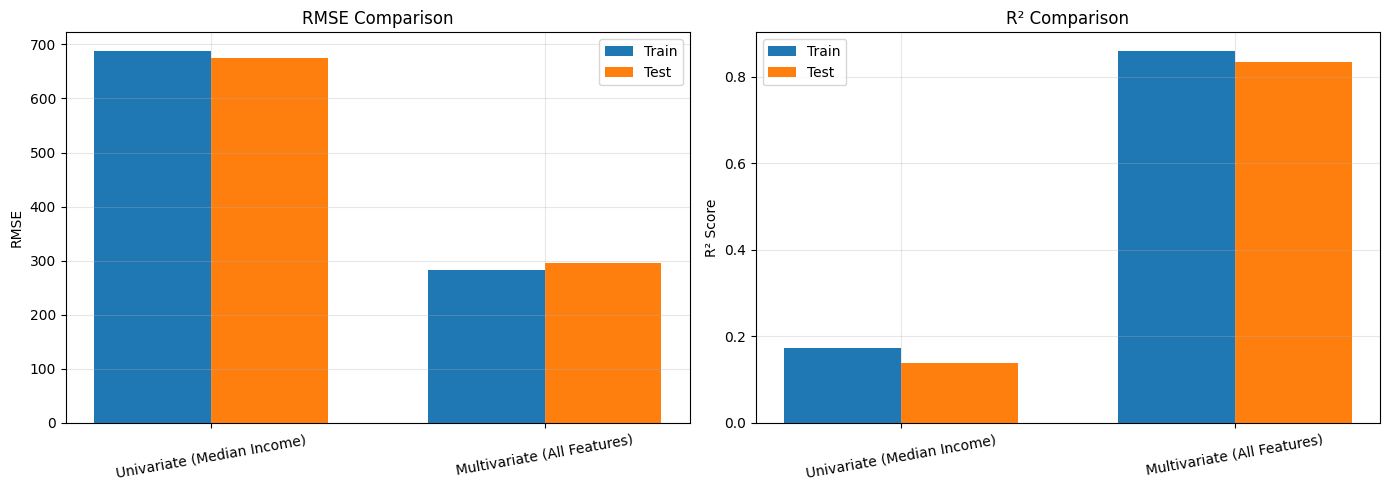

In [ ]:
#visualize
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
models = comparison["Model"]
x = np.arange(len(models))
width = 0.35
# ----------------------------
# RMSE Comparison
# ----------------------------
axes[0].bar(
x - width/2,
comparison["Train RMSE"],
width,
label="Train"
)
axes[0].bar(
x + width/2,
comparison["Test RMSE"],
width,
label="Test"
)
axes[0].set_xticks(x)
axes[0].set_xticklabels(models, rotation=10)
axes[0].set_ylabel("RMSE")
axes[0].set_title("RMSE Comparison")
axes[0].legend()
axes[0].grid(alpha=0.3)
# ----------------------------
# R² Comparison
# ----------------------------
axes[1].bar(
x - width/2,
comparison["Train R²"],
width,
label="Train"
)
axes[1].bar(
x + width/2,
comparison["Test R²"],
width,
label="Test"
)
axes[1].set_xticks(x)
axes[1].set_xticklabels(models, rotation=10)
axes[1].set_ylabel("R² Score")
axes[1].set_title("R² Comparison")
axes[1].legend()
axes[1].grid(alpha=0.3)
plt.tight_layout()
plt.show()

# **Part 6: Interpretation Questions**

**Question 1: Which model performed better?**

The Multivariate (All Features) model performed better.

**Reason:**
- It achieved a much lower **Test RMSE (296.47)** than the Univariate model **(674.03)**, indicating smaller prediction errors.
- It achieved a much higher **Test $R^2$ score (0.83)** than the Univariate model **(0.14)**, meaning it explains much more of the variation in sales.


**Question 2: Why is the Multivariate model expected to perform better than the Univariate model?**

The Multivariate model is expected to perform better because:
- It uses multiple predictive features instead of relying on only one feature.
- Sales are influenced by several factors, including volume sold, average price, product size, and time.
- Combining multiple features enables the model to capture more complex relationships, resulting in better prediction accuracy.


**Question 3: Which feature appears to have the greatest influence on sales? Support your answer using the coefficient table**.

Based on the coefficient table, **volume_sales** has the greatest influence on **value_sales** because it has the largest absolute coefficient (**631.40**).

The second most influential feature is **average_price**, with a coefficient of **275.56**. This indicates that these two variables contribute the most to predicting sales.


**Question 4: What does a negative coefficient mean?**

A negative coefficient indicates an **inverse relationship** between the feature and the target variable.

For example, the coefficient for **month** is **-8.16**, which means that, while holding the other features constant, an increase in the standardized month value is associated with a small decrease in the predicted **value_sales**.


**Question 5: If the $R^2$ score is 0.82, what does this tell us about the model?**

An $R^2$ score of **0.82** means that the model explains approximately **82% of the variation** in **value_sales**.

This indicates that the model has a strong fit, while the remaining **18%** of the variation is due to factors not included in the model or random variation.


**Question 6: Why should we evaluate the model using the test set instead of the training set?**

The test set contains unseen data that were not used during model training.

Evaluating the model on the test set measures how well it generalizes to new data and helps detect overfitting, where a model performs well on the training data but poorly on unseen data.